In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv(r"D:\Dataset\Internship Fraud Detection\features_engineered.csv")
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
models = {
    'Logistic Regression': joblib.load(r'D:\Dataset\Internship Fraud Detection\models\logistic_model.pkl'),
    'Decision Tree': joblib.load(r'D:\Dataset\Internship Fraud Detection\models\decision_tree.pkl'),
    'Random Forest': joblib.load(r'D:\Dataset\Internship Fraud Detection\models\random_forest.pkl'),
    'XGBoost': joblib.load(r'D:\Dataset\Internship Fraud Detection\models\xgboost_model.pkl'),
}

In [6]:
scaler = joblib.load(r'D:\Dataset\Internship Fraud Detection\models\scaler.pkl')


In [11]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

results = []

for name, model in models.items():

    # ==============================
    # PREDICTION
    # ==============================

    if name == "Logistic Regression":

        X_test_scaled = scaler.transform(X_test)

        y_pred = model.predict(
            X_test_scaled
        )

        y_proba = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_pred = model.predict(
            X_test
        )

        y_proba = model.predict_proba(
            X_test
        )[:, 1]


    # ==============================
    # CONFUSION MATRIX
    # ==============================

    cm = confusion_matrix(
        y_test,
        y_pred
    )


    # ==============================
    # ROC CURVE
    # ==============================

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_proba
    )


    # ==============================
    # MODEL RESULTS
    # ==============================

    results.append({

        "Model": name,

        "Accuracy": model.score(
            X_test_scaled
            if name == "Logistic Regression"
            else X_test,
            y_test
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_proba
        ),

        # Actual confusion matrix
        "confusion_matrix":
            cm.tolist(),

        # Actual ROC curve
        "fpr":
            fpr.tolist(),

        "tpr":
            tpr.tolist()

    })


# ==============================
# DATAFRAME
# ==============================

results_df = pd.DataFrame(
    results
)

print(
    "Model Comparison:"
)

print(
    results_df.to_string()
)

Model Comparison:
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC           confusion_matrix                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [10]:
import json

with open(r"D:\Dataset\Internship Fraud Detection\models\model_performance.json", "w") as file:
    json.dump(results, file, indent=4)

print("Model performance saved successfully!")

Model performance saved successfully!


In [13]:
import json

with open(r"D:\Dataset\Internship Fraud Detection\models\model_performance.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        results,
        file,
        indent=4
    )

print(
    "Model performance saved successfully."
)

Model performance saved successfully.


C:\Users\user\AppData\Local\Temp\ipykernel_15060\1052538249.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


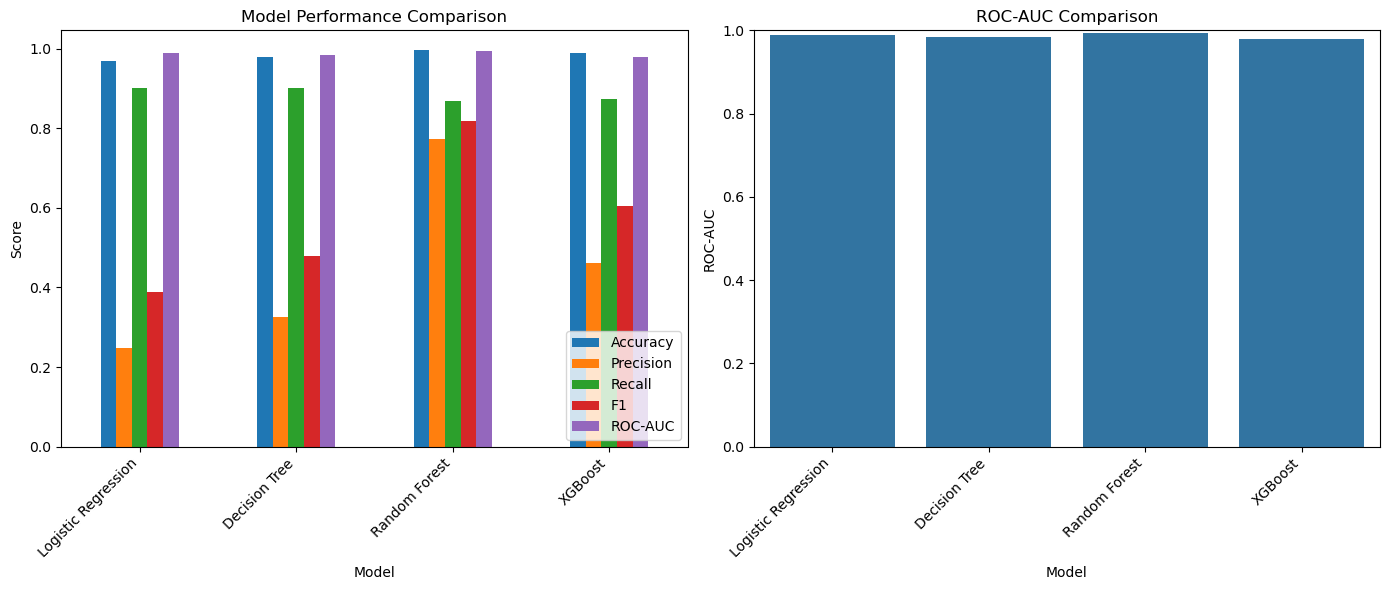

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Metrics comparison
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# ROC-AUC comparison
sns.barplot(data=results_df, x='Model', y='ROC-AUC', ax=axes[1])
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [10]:
best_model = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
print(f"\nBest Model: {best_model}")


Best Model: Random Forest


In [14]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

results = []

for name, model in models.items():

    # ==============================
    # PREDICTION
    # ==============================

    if name == "Logistic Regression":

        X_test_scaled = scaler.transform(X_test)

        y_pred = model.predict(
            X_test_scaled
        )

        y_proba = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_pred = model.predict(
            X_test
        )

        y_proba = model.predict_proba(
            X_test
        )[:, 1]


    # ==============================
    # CONFUSION MATRIX
    # ==============================

    cm = confusion_matrix(
        y_test,
        y_pred
    )


    # ==============================
    # ROC CURVE
    # ==============================

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_proba
    )


    # ==============================
    # FEATURE IMPORTANCE
    # ==============================

    feature_importance = []


    if hasattr(model, "feature_importances_"):

        importances = model.feature_importances_

        feature_names = X_train.columns


        for feature, importance in zip(
            feature_names,
            importances
        ):

            feature_importance.append({

                "feature":
                    feature,

                "importance":
                    float(importance)

            })


        # Highest importance first

        feature_importance.sort(
            key=lambda x: x["importance"],
            reverse=True
        )


    # ==============================
    # LOGISTIC REGRESSION
    # ==============================

    elif name == "Logistic Regression":

        coefficients = model.coef_[0]

        feature_names = X_train.columns


        for feature, coefficient in zip(
            feature_names,
            coefficients
        ):

            feature_importance.append({

                "feature":
                    feature,

                "importance":
                    float(abs(coefficient))

            })


        feature_importance.sort(
            key=lambda x: x["importance"],
            reverse=True
        )


    # ==============================
    # MODEL RESULTS
    # ==============================

    results.append({

        "Model": name,

        "Accuracy": model.score(
            X_test_scaled
            if name == "Logistic Regression"
            else X_test,
            y_test
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_proba
        ),

        # Actual confusion matrix
        "confusion_matrix":
            cm.tolist(),

        # Actual ROC curve
        "fpr":
            fpr.tolist(),

        "tpr":
            tpr.tolist(),

        # Actual feature importance
        "feature_importance":
            feature_importance

    })


# ==============================
# DATAFRAME
# ==============================

results_df = pd.DataFrame(
    results
)


print(
    "Model Comparison:"
)

print(
    results_df.to_string()
)

Model Comparison:
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC           confusion_matrix                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [15]:
import json

with open(r"D:\Dataset\Internship Fraud Detection\models\model_performance.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        results,
        file,
        indent=4
    )

print(
    "Model performance saved successfully."
)

Model performance saved successfully.
